In [3]:
import cx_Oracle
import itertools
import joblib
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
# import missingno as msno

In [4]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import  accuracy_score,roc_auc_score,average_precision_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from functools import  reduce

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
%matplotlib inline
sns.set_style('whitegrid')
from matplotlib import font_manager
font_path='/usr/share/fonts/cjkuni-uming/uming.ttc'
matplotlib.rcParams['font.family']=font_manager.FontProperties(fname=font_path).get_name()
matplotlib.rcParams['axes.unicode_minus']=False

In [216]:
import warnings
warnings.filterwarnings('ignore')

In [217]:
%matplotlib inline

In [5]:

#读取基金名称和月份数据，合并并清理空值，将每行的基金名称和其对应的非空月份分别存入两个列表
def clean_and_split_months(fund_names_path,months_path):
    #读取数据
    months_df=pd.read_csv(fund_names_path)
    fund_names_df=pd.read_csv(months_path)
    #合并数据框
    months_with_fund=pd.concat([fund_names_df,months_df],axis=1)
    #清理空值并将每一行的非空值提取为列表
    result_cleaned = months_with_fund.apply(lambda row: row.dropna().tolist(), axis=1)
    #分离基金名称和其对应的非空月份
    res = []
    for x in result_cleaned:
        if len(x) > 1:   #确保至少有基金名称和至少一个月份
            res.append(x)
    fund_names = [sublist[0] for sublist in res]
    months_list = [sublist[1:] for sublist in res]

    return fund_names,months_list

In [6]:
#相关股票数据信息读取与处理
fund_names_path='data/fund/eda/months_df.csv'
months_path='data/fund/eda/fund_names_df.csv'
fund_names,months_list=clean_and_split_months(fund_names_path,months_path)

In [7]:
#DP的SHAP值小于0.1且正样本过少：004098.OF({0: 8701, 1: 3}),563180.OF({0: 4362, 1: 10}),007178.OF({0: 2974, 1: 2}),007216.OF({0: 2974, 1: 2})，015290.OF({0: 12878, 1: 19})，015289.OF({0: 12878, 1: 19})
remove_list=['004098.OF','563180.OF','007178.OF','007216.OF','015290.OF','015289.OF']
fund_names=[item for item in fund_names if item not in remove_list]

In [11]:
months_list

[[201906.0,
  201912.0,
  202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0],
 [201712.0,
  201806.0,
  201812.0,
  201906.0,
  201912.0,
  202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [202312.0, 202406.0],
 [202306.0, 202312.0, 202406.0],
 [201912.0,
  202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [201712.0,
  201806.0,
  201812.0,
  201906.0,
  201912.0,
  202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [201806.0,
  201812.0,
  201906.0,
  201912.0,
  202006.0,
  202012.0,
  202106.0,
  202112.0,
  202206.0,
  202212.0,
  202306.0,
  202312.0,
  202406.0],
 [201903.0,
  201906.0,
 

In [9]:
fund_name=fund_names[0]

In [166]:
#加载time_simple_eda.ipynb处理好的特征标签文件time_series_eda_202411.csv  2022-09---2024-11
#加载和合并数据
all_data=[] #存储所有月份的数据
for month in months_list[0]:
    month=int(month)
    df=pd.read_csv(f'data/fund/eda/{fund_name}_eda_{month}.csv')
    df['month']=month
    all_data.append(df)

In [167]:
data=pd.concat(all_data,ignore_index=True)
data.head()

,CJJG_CODE,CJJG_OP_YOY,CJJG_OP_TTM_YOY,CJJG_CP_YOY,CJJG_CP_TTM_YOY,CJJG_NP_YOY,CJJG_NP_TTM_YOY,CJJG_NPAT_YOY,CJJG_NPAT_TTM_YOY,CJJG_DNP_YOY,...,CJJG_VOL_60,CJJG_VOL_240,CJJG_RES_VOL_10,CJJG_RES_VOL_20,CJJG_RES_VOL_60,CJJG_SR_10,CJJG_SR_20,CJJG_SR_60,label,month
0,300223.SZ,-0.183175,0.568975,0.338788,0.646706,-0.173678,0.752528,-0.173678,0.752528,0.351957,...,0.045127,0.031918,0.063357,0.055694,0.044593,0.023370,0.037427,0.006970,0,201906
1,300224.SZ,-0.887866,-2.192115,-0.272875,-0.065246,-0.773569,-1.920483,-0.724391,-1.820968,-0.725652,...,0.040825,0.030539,0.057236,0.048217,0.035039,0.148840,0.241911,0.250883,0,201906
2,300225.SZ,-0.428100,-0.883635,0.122011,-0.172045,-0.437275,-0.833687,-0.372695,-0.814189,-0.423236,...,0.039013,0.042365,0.018812,0.018464,0.030911,0.242530,0.702322,0.361604,0,201906
3,300226.SZ,0.634002,1.424176,0.340440,0.527161,0.695789,1.426339,0.580813,1.118643,0.884800,...,0.035698,0.033578,0.017136,0.017722,0.029019,0.218411,0.681830,0.327994,0,201906
4,300227.SZ,-0.105612,0.095374,0.194730,0.056757,-0.188035,0.026638,-0.202302,-0.011705,-0.160551,...,0.032074,0.026324,0.018866,0.015372,0.027496,0.020660,0.556336,0.252631,0,201906


In [191]:
#特征与标签,股票代码列分离
X=data.drop(columns=['CJJG_CODE','label','month'])

In [192]:
X.head()

,CJJG_OP_YOY,CJJG_OP_TTM_YOY,CJJG_CP_YOY,CJJG_CP_TTM_YOY,CJJG_NP_YOY,CJJG_NP_TTM_YOY,CJJG_NPAT_YOY,CJJG_NPAT_TTM_YOY,CJJG_DNP_YOY,CJJG_DNP_TTM_YOY,...,CJJG_VOL_10,CJJG_VOL_20,CJJG_VOL_60,CJJG_VOL_240,CJJG_RES_VOL_10,CJJG_RES_VOL_20,CJJG_RES_VOL_60,CJJG_SR_10,CJJG_SR_20,CJJG_SR_60
0,-0.183175,0.568975,0.338788,0.646706,-0.173678,0.752528,-0.173678,0.752528,0.351957,0.096201,...,0.067578,0.058241,0.045127,0.031918,0.063357,0.055694,0.044593,0.023370,0.037427,0.006970
1,-0.887866,-2.192115,-0.272875,-0.065246,-0.773569,-1.920483,-0.724391,-1.820968,-0.725652,-15.379107,...,0.065394,0.056817,0.040825,0.030539,0.057236,0.048217,0.035039,0.148840,0.241911,0.250883
2,-0.428100,-0.883635,0.122011,-0.172045,-0.437275,-0.833687,-0.372695,-0.814189,-0.423236,-0.933103,...,0.022783,0.034721,0.039013,0.042365,0.018812,0.018464,0.030911,0.242530,0.702322,0.361604
3,0.634002,1.424176,0.340440,0.527161,0.695789,1.426339,0.580813,1.118643,0.884800,0.984020,...,0.020432,0.032234,0.035698,0.033578,0.017136,0.017722,0.029019,0.218411,0.681830,0.327994
4,-0.105612,0.095374,0.194730,0.056757,-0.188035,0.026638,-0.202302,-0.011705,-0.160551,-0.084714,...,0.020095,0.023678,0.032074,0.026324,0.018866,0.015372,0.027496,0.020660,0.556336,0.252631


In [170]:
print(X.shape)

(26954, 165)


#### 处理共线性问题

In [177]:
#计算相关系数
#Pearson相关系数，用于衡量两个连续变量之间的线性相关性
correlation_matrix=X.corr()

#二维矩阵变为一维的MultIndex Series，索引为矩阵中原始的行和列，值为对应的相关性数值
high_corr=correlation_matrix[correlation_matrix>0.9].stack()
#通过重置索引来补齐索引，通过reset_index()将MultIndex转换为DataFrame
high_corr_reset=high_corr.reset_index()
high_corr_reset.columns=['features1','features2','correlation']
#去掉重复对和features1==features2的对
high_corr_cleaned=high_corr_reset[high_corr_reset['features1']<high_corr_reset['features2']].reset_index(drop=True)


In [178]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features1=[mapping_dict.get(feature) for feature in high_corr_cleaned['features1']]
mapping_features2=[mapping_dict.get(feature) for feature in high_corr_cleaned['features2']]

In [179]:
high_corr_cleaned['mapping_features1']=mapping_features1
high_corr_cleaned['mapping_features2']=mapping_features2

In [180]:
high_corr_cleaned

,features1,features2,correlation,mapping_features1,mapping_features2
0,CJJG_CP_TTM_YOY,CJJG_CP_YOY,0.977487,主营利润_TTM_同比,主营利润_同比
1,CJJG_EBIT_YOY,CJJG_NOPLAT_YOY,1.000000,EBIT_同比,NOPLAT_同比
2,CJJG_EBIT_TTM_YOY,CJJG_NOPLAT_TTM_YOY,1.000000,EBIT_TTM_同比,NOPLAT_TTM_同比
3,CJJG_NPM,CJJG_POE,0.981719,净利润率,三项费用比例
4,CJJG_GPM,CJJG_NPM,0.998673,销售毛利率,净利润率
...,...,...,...,...,...
94,CJJG_SALES2EV_12,CJJG_SALES2EV_12_TTM,0.980751,SALES2EV_12,SALES2EV_12_TTM
95,CJJG_TR_10,CJJG_TR_20,0.947504,换手率_10,换手率_20
96,CJJG_RES_VOL_10,CJJG_VOL_10,0.977308,残差波动率_10,波动率_10
97,CJJG_RES_VOL_20,CJJG_VOL_20,0.966053,残差波动率_20,波动率_20


In [211]:
correlation_matrix['CJJG_KU_240'].sort_values(ascending=False)

CJJG_KU_240        1.000000
CJJG_KU_60         0.438979
CJJG_KU_20         0.223323
CJJG_RES_VOL_20    0.175691
CJJG_VOL_240       0.168081
                     ...   
CJJG_MOM_240      -0.246539
CJJG_SK_60        -0.256324
CJJG_MDR_20       -0.256482
CJJG_MDR_60       -0.332615
CJJG_SK_240       -0.853301
Name: CJJG_KU_240, Length: 165, dtype: float64

In [185]:
high_corr_cleaned1

,features1,features2,correlation
13,CJJG_NP_YOY,CJJG_OP_YOY,0.963248
18,CJJG_NP_TTM_YOY,CJJG_OP_TTM_YOY,0.964671
24,CJJG_NPAT_YOY,CJJG_OP_YOY,0.946324
25,CJJG_NPAT_YOY,CJJG_NP_YOY,0.977737
29,CJJG_NPAT_TTM_YOY,CJJG_OP_TTM_YOY,0.951253
...,...,...,...
417,CJJG_TR_20,CJJG_TR_60,0.919144
457,CJJG_RES_VOL_10,CJJG_VOL_10,0.951588
459,CJJG_RES_VOL_20,CJJG_RV,0.934944
460,CJJG_RES_VOL_20,CJJG_VOL_20,0.932992


In [82]:
drop_columns=['CJJG_DP','CJJG_EBIT2EV','CJJG_CP_YOY','CJJG_PORE','CJJG_EBITDA2EV','CJJG_NOPLAT2EV','CJJG_SALES2EV','CJJG_TR_10','CJJG_TR_20','CJJG_MBPM','CJJG_POE','CJJG_DIO','CJJG_DSO','CJJG_ILQ_10','CJJG_ILQ_20']

['CJJG_CP_TTM_YOY', 'CJJG_EBIT_YOY', 'CJJG_EBIT_TTM_YOY', 'CJJG_NPM', 'CJJG_GPM', 'CJJG_GPM', 'CJJG_GPM_TTM', 'CJJG_ATPROE', 'CJJG_ATPROE', 'CJJG_ATPROE_TTM', 'CJJG_ENIROE', 'CJJG_ENIROA', 'CJJG_ENIROA_TTM', 'CJJG_ARR', 'CJJG_ARR', 'CJJG_ARR_TTM', 'CJJG_ARR_TTM', 'CJJG_PORE', 'CJJG_EBIT2BI', 'CJJG_EBIT2BI', 'CJJG_EBIT2BI', 'CJJG_EBIT2BI', 'CJJG_EBIT2BI', 'CJJG_EBIT2BI_TTM', 'CJJG_EBIT2BI_TTM', 'CJJG_EBIT2BI_TTM', 'CJJG_EBITDA2BI', 'CJJG_EBITDA2BI', 'CJJG_EBITDA2BI', 'CJJG_EBITDA2BI', 'CJJG_EBITDA2BI_TTM', 'CJJG_EBITDA2BI_TTM', 'CJJG_ALR', 'CJJG_CR', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO', 'CJJG_DSO_TTM', 'CJJG_DTAT', 'CJJG_DTAT', 'CJJG_DTAT', 'CJJG_DTAT', 'CJJG_DTAT', 'CJJG_DTAT', 'CJJG_DTAT_TTM', 'CJJG_FATD', 'CJJG_FATD', 'CJJG_FATD', 'CJJG_FATD_TTM', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR', 'CJJG_CORR_TTM', 'CJJG_CORR_TTM', 'CJJG_CORR_TTM', 'CJJG_CORR_TTM', 'CJJG_CCLR', 'CJJG_CC

In [189]:
drop_columns = ['CJJG_DP', 'CJJG_EBIT2EV', 'CJJG_CP_YOY', 'CJJG_PORE', 'CJJG_EBITDA2EV', 'CJJG_NOPLAT2EV',
                         'CJJG_SALES2EV', 'CJJG_TR_10', 'CJJG_TR_20', 'CJJG_MBPM', 'CJJG_POE', 'CJJG_DIO', 'CJJG_DSO',
                         'CJJG_ILQ_10', 'CJJG_ILQ_20']
X = X.drop(columns=['CJJG_DP'])

KeyError: "['CJJG_DP', 'CJJG_EBIT2EV', 'CJJG_CP_YOY', 'CJJG_PORE', 'CJJG_EBITDA2EV', 'CJJG_NOPLAT2EV', 'CJJG_SALES2EV', 'CJJG_TR_10', 'CJJG_TR_20', 'CJJG_MBPM', 'CJJG_POE', 'CJJG_DIO', 'CJJG_DSO', 'CJJG_ILQ_10', 'CJJG_ILQ_20'] not found in axis"

In [190]:
X

,CJJG_CODE,CJJG_OP_YOY,CJJG_OP_TTM_YOY,CJJG_CP_TTM_YOY,CJJG_NP_YOY,CJJG_NP_TTM_YOY,CJJG_NPAT_YOY,CJJG_NPAT_TTM_YOY,CJJG_DNP_YOY,CJJG_DNP_TTM_YOY,...,CJJG_VOL_60,CJJG_VOL_240,CJJG_RES_VOL_10,CJJG_RES_VOL_20,CJJG_RES_VOL_60,CJJG_SR_10,CJJG_SR_20,CJJG_SR_60,label,month
0,300223.SZ,-0.183175,0.568975,0.646706,-0.173678,0.752528,-0.173678,0.752528,0.351957,0.096201,...,0.045127,0.031918,0.063357,0.055694,0.044593,0.023370,0.037427,0.006970,0,201906
1,300224.SZ,-0.887866,-2.192115,-0.065246,-0.773569,-1.920483,-0.724391,-1.820968,-0.725652,-15.379107,...,0.040825,0.030539,0.057236,0.048217,0.035039,0.148840,0.241911,0.250883,0,201906
2,300225.SZ,-0.428100,-0.883635,-0.172045,-0.437275,-0.833687,-0.372695,-0.814189,-0.423236,-0.933103,...,0.039013,0.042365,0.018812,0.018464,0.030911,0.242530,0.702322,0.361604,0,201906
3,300226.SZ,0.634002,1.424176,0.527161,0.695789,1.426339,0.580813,1.118643,0.884800,0.984020,...,0.035698,0.033578,0.017136,0.017722,0.029019,0.218411,0.681830,0.327994,0,201906
4,300227.SZ,-0.105612,0.095374,0.056757,-0.188035,0.026638,-0.202302,-0.011705,-0.160551,-0.084714,...,0.032074,0.026324,0.018866,0.015372,0.027496,0.020660,0.556336,0.252631,0,201906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26949,001298.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.018652,0.025403,0.034628,0.144759,0.085408,0.235737,0,202212
26950,001299.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.050063,0.054929,0.058186,0.012097,0.060462,0.001890,0,202212
26951,001300.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.017075,0.037129,0.058282,0.467671,0.003465,0.051284,0,202212
26952,001322.SZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.031954,0.033150,0.037631,0.394997,0.160224,0.269741,0,202212


In [182]:
#计算斯皮尔曼相关系数，衡量两个变量之间的等级关系的强度和方向，不要求变量之间的关系是线性的
correlation_matrix1=X.corr(method='spearman')

In [183]:
#二维矩阵变为一维的MultIndex Series，索引为矩阵中原始的行和列，值为对应的相关性数值
high_corr1=correlation_matrix1[correlation_matrix1>0.9].stack()
#通过重置索引来补齐索引，通过reset_index()将MultIndex转换为DataFrame
high_corr_reset1=high_corr1.reset_index()
high_corr_reset1.columns=['features1','features2','correlation']
#去掉重复对和features1==features2的对
high_corr_cleaned1=high_corr_reset1[high_corr_reset1['features1']<high_corr_reset1['features2']]

In [184]:
high_corr_cleaned1

,features1,features2,correlation
13,CJJG_NP_YOY,CJJG_OP_YOY,0.963248
18,CJJG_NP_TTM_YOY,CJJG_OP_TTM_YOY,0.964671
24,CJJG_NPAT_YOY,CJJG_OP_YOY,0.946324
25,CJJG_NPAT_YOY,CJJG_NP_YOY,0.977737
29,CJJG_NPAT_TTM_YOY,CJJG_OP_TTM_YOY,0.951253
...,...,...,...
417,CJJG_TR_20,CJJG_TR_60,0.919144
457,CJJG_RES_VOL_10,CJJG_VOL_10,0.951588
459,CJJG_RES_VOL_20,CJJG_RV,0.934944
460,CJJG_RES_VOL_20,CJJG_VOL_20,0.932992


In [143]:
correlation_matrix1['CJJG_REV_10'].sort_values(ascending=False)

CJJG_REV_10     1.000000
CJJG_REV_20     0.608683
CJJG_MCI_10     0.607455
CJJG_MDD_10     0.542065
CJJG_MDD_20     0.522695
                  ...   
CJJG_WC        -0.086740
CJJG_SR_10     -0.096007
CJJG_BETA_60   -0.117948
CJJG_SR_20     -0.130638
CJJG_BETA_20   -0.179414
Name: CJJG_REV_10, Length: 165, dtype: float64

In [212]:
months

NameError: name 'months' is not defined

In [238]:
tmp=['2012-12','2014-12','2022-12','2024-12','2023-12','2024-01']
tmp

['2012-12', '2014-12', '2022-12', '2024-12', '2023-12', '2024-01']

In [227]:
from datetime import datetime
#字段串转换为datetime对象
month_date=datetime.strptime(month,'%Y-%m')
#设定一个基准日期，2024年1月1日
comparison_date=datetime(2024,1,1)
#判断是否小于2024年
if month_date<comparison_date:
    print('yes')
else:
    print('no')

yes


In [239]:
#筛选24年以前的月份
filter_month=[month for month in tmp if datetime.strptime(month,'%Y-%m')<comparison_date]

In [240]:
filter_month

['2012-12', '2014-12', '2022-12', '2023-12']

In [226]:
print(month_date)

2022-12-01 00:00:00


In [20]:
y=data['label']

In [21]:
y.shape

(26954,)

In [23]:
y_code=data[['CJJG_CODE','label']]

In [24]:
y_code.head()

,CJJG_CODE,label
0,300223.SZ,0
1,300224.SZ,0
2,300225.SZ,0
3,300226.SZ,0
4,300227.SZ,0


In [25]:
#模型评估指标函数，打印Recall和F1
def metric_score(test_y,pre_y):
    #模型评估
    accuracy=accuracy_score(test_y,pre_y)
    auroc=roc_auc_score(test_y,pre_y)
    aupr=average_precision_score(test_y,pre_y)
    f1=f1_score(test_y,pre_y)
    precision=precision_score(test_y,pre_y)
    recall=recall_score(test_y,pre_y)
    
    #分类报告
    report=classification_report(test_y,pre_y)
    
    # print(report)
    print("Recall:%.3f"% recall)
    print("Precision:%.3f"% precision)
    print("F1:%.3f"% f1)

In [26]:
def plot_confusion_matrix(cm,classes,fund_name,cmap=plt.cm.Blues):
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(f'{fund_name}_confusion_matrix')
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes)
    plt.yticks(tick_marks,classes)
    
    thresh=cm.max()/2
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],horizontalalignment='center',color='white' if cm[i,j]>thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predict label')
    plt.savefig(f'data/fund/fig/{fund_name}_confusion_matrix.svg')

In [27]:
stockcode_name=pd.read_csv('data/stockcode_name.csv')
stockcode_name

,STOCKCODE,SESNAME
0,837758.BJ,宏天信业(IPO终止)
1,300508.SZ,维宏股份
2,300551.SZ,古鳌科技
3,002835.SZ,同为股份
4,002601.SZ,龙佰集团
...,...,...
5832,688819.SH,天能股份
5833,300935.SZ,盈建科
5834,003042.SZ,中农联合
5835,301235.SZ,华康医疗


In [28]:
#加载因子名字文件
factor_name=pd.read_csv('data/factor_name.csv')
factor_name

,COLUMNAME,FACTORNAME
0,cjjg_smv_63,聪明钱v_63
1,cjjg_smr_21,聪明钱排序_21
2,cjjg_smr_63,聪明钱排序_63
3,CJJG_STM_5_10,短期动量_5_10
4,CJJG_STER_5_10,短期加强反转_5_10
...,...,...
554,CJJG_CFAPM_20,集合替APM_20
555,CJJG_COAPM_20,集合APM_20
556,CJJG_TPR_20,时量价比_20
557,CJJG_TPR_10,时量价比_10


In [68]:
#统一因子字段为大写
factor_name['COLUMNAME']=factor_name['COLUMNAME'].str.upper()
#创建映射字典
mapping_dict=factor_name.set_index('COLUMNAME')['FACTORNAME'].to_dict()
mapping_dict

{'CJJG_SMV_63': '聪明钱v_63',
 'CJJG_SMR_21': '聪明钱排序_21',
 'CJJG_SMR_63': '聪明钱排序_63',
 'CJJG_STM_5_10': '短期动量_5_10',
 'CJJG_STER_5_10': '短期加强反转_5_10',
 'CJJG_ESIEF': '高管增持事件因子',
 'CJJG_NPEF': '负向业绩预告事件因子',
 'CJJG_NPEEF': '负向业绩快报事件因子',
 'CJJG_LUF': '涨停事件因子',
 'CJJG_LREF': '领涨事件因子',
 'CJJG_ESEF': '事件外溢效应因子',
 'CJJG_ER_5_10': '极端收益_5_10',
 'CJJG_DF_VP_TCN': '日频_量价_TCN',
 'CJJG_M1_VP_TCN': '1分钟_量价_TCN',
 'CJJG_DF_1M_VP_TCN': '日频_1分钟_量价_TCN',
 'CJJG_ILLQ_240_20': '非流动性_240_20',
 'CJJG_PATHILLQ_240_20': '路径非流动性_240_20',
 'CJJG_TRAJILLQ_240_20': '轨迹非流动性_240_20',
 'CJJG_REGILLQ_240_20': '回归非流动性_240_20',
 'CJJG_UDILLQ_RATIO_240_20': '上下行非流动性比_240_20',
 'CJJG_TPR_5_20': '时量价比_5_20',
 'CJJG_HPA_5_20': '高价振幅_5_20',
 'CJJG_LPA_5_20': '低价振幅_5_20',
 'CJJG_HPTP_5_20': '高价成交占比_5_20',
 'CJJG_LPTP_5_20': '低价成交占比_5_20',
 'CJJG_VWR_5_20': '成交量加权反转_5_20',
 'CJJG_HVTC_5_20': '高量交易成本_5_20',
 'CJJG_HVPT_5_20': '高量每笔成交_5_20',
 'CJJG_LVTC_5_20': '低量交易成本_5_20',
 'CJJG_LVPT_5_20': '低量每笔成交_5_20',
 'CJJG_HDTC_5_20': '高

In [134]:
#训练集测试集划分，训练集放入全部正样本，负样本进行欠采样，预测时放入全部样本
#保留正样本，欠采样负样本
rus=RandomUnderSampler(sampling_strategy=0.1) #比例1：10
X_train_rus,y_train_rus=rus.fit_resample(X,y)
X_test,y_test=X,y

In [135]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y))

Before undersampling: Counter({0: 36547, 1: 570})


In [136]:
#欠采样后类别占比情况
print("After undersampling:",Counter(y_train_rus))

After undersampling: Counter({0: 5700, 1: 570})


In [137]:
#训练多个模型并存储
#模型存储列表
models=[]

for i in range(30):
    rus=RandomUnderSampler(sampling_strategy=0.1) #比例1：10
    X_train_rus,y_train_rus=rus.fit_resample(X,y)
    xgb_model=XGBClassifier()
    xgb_model.fit(X_train_rus,y_train_rus)
    
    #特征重要性（SHAP值）
    explainer=shap.Explainer(xgb_model)
    shape_value=explainer.shap_values(X)
    shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)
    #输出每个特征的SHAP值（绝对值）
    features=[]
    shap_values_means=[]
    for index,feature in enumerate(X_train_rus.columns):
        shap_values_mean=np.abs(shap_df.values[:,index]).mean()
        features.append(feature)
        shap_values_means.append(shap_values_mean)
    tt=pd.DataFrame(features,columns=['features'])
    tt['shap_values']=shap_values_means
    tt_sort=tt.sort_values(by='shap_values',ascending=False)
    tt_sort.to_csv(f'data/fund/xgb_{fund_name}_feature_importance{i}.csv',index=False)
    
    #保存模型
    model_filename=f'data/fund/xgb_{fund_name}_model_{i}.pkl'
    joblib.dump(xgb_model,model_filename)
    models.append(xgb_model)
X_train_rus,y_train_rus=rus.fit_resample(X,y)

In [138]:
#加载所有保存的模型
models=[joblib.load(f'data/fund/xgb_{fund_name}_model_{i}.pkl') for i in range(30)]

#对所有模型进行投票集成,选择硬投票或软投票(基于概率）
voting_clf=VotingClassifier(estimators=[(f'xgb_{fund_name}_model_{i}',model) for i,model in enumerate(models)],
                            voting='soft')
voting_clf.fit(X_train_rus,y_train_rus)
#保存模型
model_filename=f'data/fund/voting_{fund_name}_model.pkl'
joblib.dump(voting_clf,model_filename)
y_pred=voting_clf.predict(X_test)
metric_score(test_y=y_test,pre_y=y_pred)

Recall:1.000
Precision:0.589
F1:0.742


In [139]:
#查看模型预测为1，实际为0的股票
#原始数据处理
result_df1=y_code.reset_index()
result_copy=result_df1.copy()
result_copy['y_true']=y_test
result_copy['y_pred']=y_pred

false_pos=result_copy[(result_copy['y_pred']==1) & (result_copy['y_true']==0)]
#合并股票名称
false_pos_df1=pd.merge(false_pos['CJJG_CODE'],stockcode_name,left_on='CJJG_CODE',right_on='STOCKCODE',how='inner')
#添加重复次数列
false_pos_df1['count']=false_pos_df1.groupby('STOCKCODE')['STOCKCODE'].transform('count')
false_pos_df1=false_pos_df1[['STOCKCODE','SESNAME','count']].drop_duplicates().reset_index(drop=True)
false_pos_df1.to_csv(f'data/fund/voting_{fund_name}_model_predict.csv',index=False)

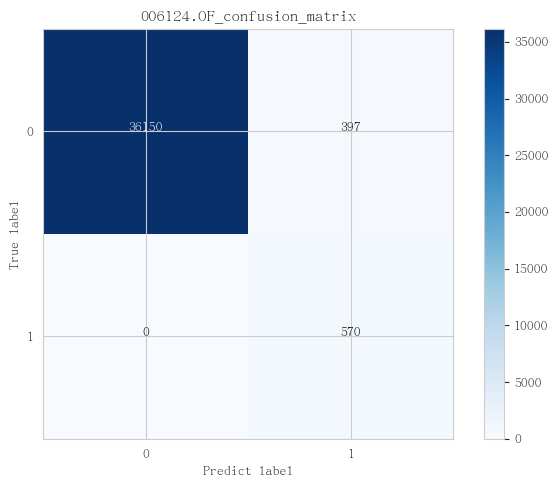

In [140]:
#默认阈值一般为0.5
y_pred_recall=y_pred[0:]>0.5
cnf_matrix=confusion_matrix(y_test,y_pred_recall)
class_names=[0,1]
plot_confusion_matrix(cnf_matrix,classes=class_names,fund_name=fund_name)

In [141]:
#读取股票名文件
voting_result=pd.read_csv(f'data/fund/voting_{fund_name}_model_predict.csv')
voting_result

,STOCKCODE,SESNAME,count
0,601009.SH,南京银行,4
1,600104.SH,上汽集团,1
2,601088.SH,中国神华,5
3,601966.SH,玲珑轮胎,2
4,601985.SH,中国核电,2
...,...,...,...
216,002415.SZ,海康威视,1
217,000895.SZ,双汇发展,1
218,002128.SZ,电投能源,1
219,000900.SZ,现代投资,1


In [142]:
#特征重要性读取
feature_file_names=[f'data/fund/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]

importance_features = []     
for file in feature_file_names:
    df=pd.read_csv(file)
    importance_features.append(df)
    
#横向拼接所有数据
importance_all=pd.concat(importance_features)

#按特征分组，计算特征重要性平均值，并排序
importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))

In [143]:
importance_summary

,features,mean,std
72,CJJG_ILQ_60,0.574662,0.083404
60,CJJG_ENIROE_TTM,0.563884,0.093437
69,CJJG_ILQ,0.519864,0.052756
34,CJJG_DP,0.352483,0.079432
76,CJJG_KU_60,0.307300,0.041660
...,...,...,...
101,CJJG_NOPLAT2EV_12_TTM,0.000000,0.000000
99,CJJG_NOPLAT2EV,0.000000,0.000000
104,CJJG_NOPLAT_TTM_YOY,0.000000,0.000000
105,CJJG_NOPLAT_YOY,0.000000,0.000000


In [144]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in importance_summary['features'][:15]]
mapping_features

['非流动性_60',
 '扣非ROE_TTM',
 '非流动性',
 'DP',
 '峰度_60',
 'ROE_TTM',
 '研发费用比例_TTM',
 '非流动性_20',
 '换手率_60',
 '空头意愿',
 '非流动性_10',
 '波动率_240',
 '峰度_10',
 '动量_240',
 'DP_TTM']

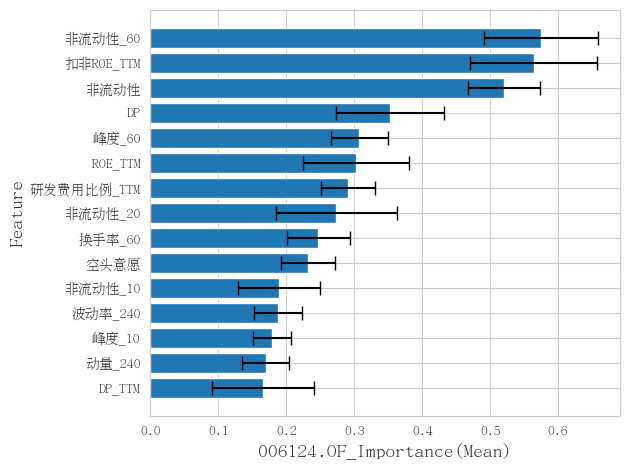

In [145]:
plt.barh(mapping_features,importance_summary['mean'][:15],xerr=importance_summary['std'][:15],capsize=5)
plt.xlabel(f'{fund_name}_Importance(Mean)',fontsize=14)
plt.ylabel('Feature',fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'data/fund/fig/{fund_name}_Importance(Mean).svg')

In [921]:
#相关股票数据信息读取与处理
fund_names_path='data/fund/eda/months_df.csv'
months_path='data/fund/eda/fund_names_df.csv'
fund_names,months_list=clean_and_split_months(fund_names_path,months_path)

In [922]:
len(fund_names)

28

In [11]:
#DP的SHAP值小于0.1且正样本过少：004098.OF({0: 8701, 1: 3}),563180.OF({0: 4362, 1: 10}),007178.OF({0: 2974, 1: 2}),007216.OF({0: 2974, 1: 2})，015290.OF({0: 12878, 1: 19})，015289.OF({0: 12878, 1: 19})
remove_list=['004098.OF','563180.OF','007178.OF','007216.OF','015290.OF','015289.OF']
fund_names=[item for item in fund_names if item not in remove_list]

In [924]:
len(fund_names)

22

In [768]:
fund_name=fund_names[0]

In [769]:
for i,fund_name in enumerate(fund_names):
    print(fund_name)

005770.OF
004404.OF
006124.OF
004403.OF
008705.OF
008737.OF
501308.OF
512590.OF
009501.OF
515690.OF
008480.OF
008481.OF
004868.OF
501307.OF
006123.OF
009500.OF
003702.OF
000916.OF
008736.OF
008177.OF
008704.OF
009188.OF


In [58]:
fund_name=fund_names[7]

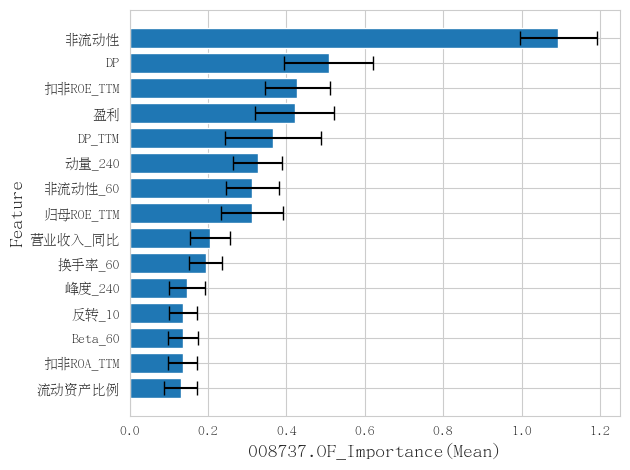

In [59]:

#特征重要性读取
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    #替换特征名字，如果找不到映射，使用原名字
    mapping_features=[mapping_dict.get(feature) for feature in importance_summary['features'][:15]]
    
    plt.barh(mapping_features,importance_summary['mean'][:15],xerr=importance_summary['std'][:15],capsize=5)
    plt.xlabel(f'{fund_name}_Importance(Mean)',fontsize=14)
    plt.ylabel('Feature',fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'data/fund/fig/{fund_name}_Importance(Mean).svg')

### top5feature筛选方案

In [925]:
#所有基金的top5特征列表
top5_features_list=[]
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    #基于SHAP平均值选择top5的特征
    top5_features=importance_summary.head(5)

    
    top5_features_list.append(top5_features)
    
    # #替换特征名字，如果找不到映射，使用原名字
    # mapping_features=[mapping_dict.get(feature) for feature in top15_features['features']]

In [926]:
len(top5_features_list)

22

In [927]:
feature_counter=Counter()   #特征出现次数
all_feature_sets=[]     #特征名字
for top5_features in top5_features_list:
    feature_names=set(top5_features['features'])
    feature_counter.update(top5_features['features']) #计数
    all_feature_sets.append(feature_names)

In [928]:
#字典转换为Dataframe
stock_frequency_df=pd.DataFrame(feature_counter.items(),columns=['name','frequency'])

#按出现次数降序
stock_frequency_df=stock_frequency_df.sort_values(by='frequency',ascending=False)
stock_frequency_df


,name,frequency
5,CJJG_ILQ,15
1,CJJG_DP,13
6,CJJG_ILQ_60,12
8,CJJG_DP_TTM,12
9,CJJG_MOM_240,7
7,CJJG_VOL_240,5
18,CJJG_KU_240,5
13,CJJG_PFT,5
10,CJJG_ENIROE_TTM,4
2,CJJG_NCFOA_TTM_YOY,3


In [929]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in stock_frequency_df['name'][:15]]

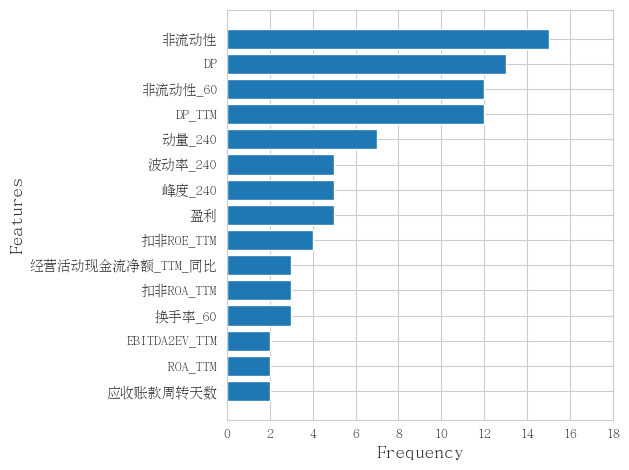

In [932]:
plt.barh(mapping_features,stock_frequency_df['frequency'][:15])
plt.xlabel('Frequency',fontsize=14)
plt.ylabel('Features',fontsize=14)
plt.gca().set_xticks(range(0,20,2))
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/TOP5_feature.svg')
# plt.close()

In [933]:
#共同的特征名字（并集）
# common_features=reduce(lambda x,y: x|y,all_feature_sets)
common_features=stock_frequency_df.reset_index(drop=True)
common_features

,name,frequency
0,CJJG_ILQ,15
1,CJJG_DP,13
2,CJJG_ILQ_60,12
3,CJJG_DP_TTM,12
4,CJJG_MOM_240,7
5,CJJG_VOL_240,5
6,CJJG_KU_240,5
7,CJJG_PFT,5
8,CJJG_ENIROE_TTM,4
9,CJJG_NCFOA_TTM_YOY,3


In [934]:
#替换特征名字，如果找不到映射，使用原名字
common_mapping_features=[mapping_dict.get(feature) for feature in common_features['name']]

In [935]:
common_mapping_features

['非流动性',
 'DP',
 '非流动性_60',
 'DP_TTM',
 '动量_240',
 '波动率_240',
 '峰度_240',
 '盈利',
 '扣非ROE_TTM',
 '经营活动现金流净额_TTM_同比',
 '扣非ROA_TTM',
 '换手率_60',
 'EBITDA2EV_TTM',
 'ROA_TTM',
 '应收账款周转天数',
 '峰度_60',
 '非流动性_10',
 '最大跌幅_60',
 '相对净利润增长',
 '相对营收增长',
 '非流动性_20',
 '绝对净利润增长',
 '商誉占比',
 '资产报酬率_TTM',
 '研发费用比例_TTM',
 '最大涨幅_60',
 '杠杆率',
 '绝对营收增长',
 '归母净利润_同比']

In [936]:
common_features['name']=common_mapping_features
common_features

,name,frequency
0,非流动性,15
1,DP,13
2,非流动性_60,12
3,DP_TTM,12
4,动量_240,7
5,波动率_240,5
6,峰度_240,5
7,盈利,5
8,扣非ROE_TTM,4
9,经营活动现金流净额_TTM_同比,3


In [937]:
common_features.columns=['feature','frequency']

In [938]:
common_features

,feature,frequency
0,非流动性,15
1,DP,13
2,非流动性_60,12
3,DP_TTM,12
4,动量_240,7
5,波动率_240,5
6,峰度_240,5
7,盈利,5
8,扣非ROE_TTM,4
9,经营活动现金流净额_TTM_同比,3


In [939]:
common_features.to_csv(f'data/fund/analyze/top5feature_union.csv', encoding='utf-8',index=False)

In [104]:
range(0,20,2)

range(0, 20, 2)

### 覆盖率80%重要性的feature筛选方案

In [940]:
#覆盖率80%重要性的特征列表
tmp1=[]
coverage80_features_list=[]
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    #选择SHAP值覆盖总重要性的80%的特征
    total_shap=importance_summary['mean'].sum()
    importance_summary['shap_cumsum']=importance_summary['mean'].cumsum()
    shap_80_percent_coverage=importance_summary[importance_summary['shap_cumsum']<=0.8*total_shap]
    tmp1.append(fund_name)
    tmp1.append(total_shap)
    print(total_shap)
    
    coverage80_features_list.append(shap_80_percent_coverage)



14.400184490426666
13.525080895426
13.129840538116667
13.420938236954
10.752992444183333
13.096832854350001
13.277992899533334
12.931868689529999
11.683672559720002
11.201294787998332
12.339127238130999
12.34370879002
12.723367313446666
13.314746109152333
13.117619578628666
11.620951742239999
13.875141920473332
12.047656694599999
13.099849039418332
11.666758678303331
10.730818430189998
11.882112731545668


In [941]:
importance_summary

,features,mean,std,shap_cumsum
118,CJJG_PFT,0.399412,0.056909,0.399412
69,CJJG_ILQ,0.354441,0.047739,0.753853
2,CJJG_ANPG,0.322223,0.043138,1.076076
107,CJJG_NPAT_YOY,0.309728,0.088188,1.385804
158,CJJG_TR_60,0.201425,0.036921,1.587229
...,...,...,...,...
104,CJJG_NOPLAT_TTM_YOY,0.000000,0.000000,11.882113
100,CJJG_NOPLAT2EV_12,0.000000,0.000000,11.882113
105,CJJG_NOPLAT_YOY,0.000000,0.000000,11.882113
101,CJJG_NOPLAT2EV_12_TTM,0.000000,0.000000,11.882113


In [942]:
feature_counter=Counter()   #特征出现次数
for coverage80_features in coverage80_features_list:
    stock_names=set(coverage80_features['features'])
    feature_counter.update(coverage80_features['features']) #计数
    
#字典转换为Dataframe
stock_frequency_df=pd.DataFrame(feature_counter.items(),columns=['name','frequency'])

#按出现次数降序
stock_frequency_df=stock_frequency_df.sort_values(by=['frequency','name'],ascending=[False,True])
stock_frequency_df

,name,frequency
81,CJJG_BETA_60,22
1,CJJG_DP,22
30,CJJG_ILQ,22
19,CJJG_ILQ_10,22
7,CJJG_ILQ_60,22
...,...,...
149,CJJG_GPM,1
150,CJJG_NPM,1
151,CJJG_NP_YOY,1
146,CJJG_RES_VOL_20,1


In [943]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in stock_frequency_df['name'][:15]]

In [944]:
mapping_features

['Beta_60',
 'DP',
 '非流动性',
 '非流动性_10',
 '非流动性_60',
 '应收账款占比',
 '流动资产比例',
 '三项费用比例_TTM',
 '商誉占比',
 '换手率_60',
 '空头意愿',
 'DP_TTM',
 '非流动性_20',
 '动量_240',
 '反转_60']

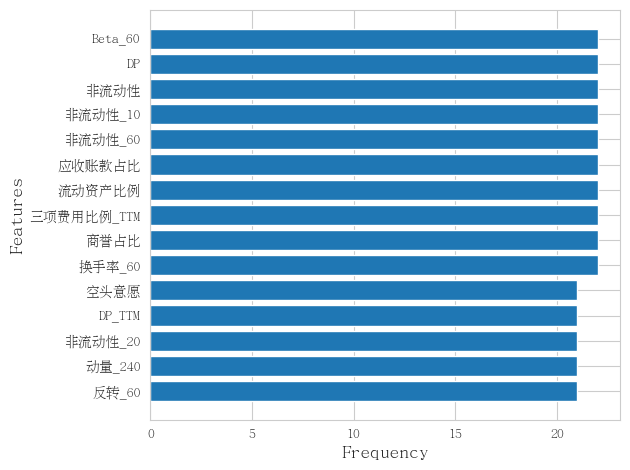

In [945]:
plt.barh(mapping_features,stock_frequency_df['frequency'][:15])
plt.xlabel('Frequency',fontsize=14)
plt.ylabel('Features',fontsize=14)
# plt.gca().set_xticks(range(0,20,2))
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/Coverage80_feature.svg')
# plt.close()

### DP特征指标80%以上卡阈值的feature筛选方案

In [946]:
#DP特征指标80%以上卡阈值的特征列表
#DP的SHAP值为0：004098.OF({0: 8701, 1: 3}),563180.OF({0: 4362, 1: 10}),007178.OF({0: 2974, 1: 2}),007216.OF({0: 2974, 1: 2})
#DP的SHAP值小于0.1：015290.OF({0: 12878, 1: 19})，015289.OF({0: 12878, 1: 19})，009188.OF({0.0: 30744, 1.0: 516})
tmp=[]
DP80_features_list=[]
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    #选择DP特征重要性大于80%的特征
    dp_threshold=importance_summary[importance_summary['features']=='CJJG_DP']['mean']*0.8
    DP80_features=importance_summary[importance_summary['mean'].values>=dp_threshold.values]
    
    print(fund_name)
    print(importance_summary[importance_summary['features']=='CJJG_DP']['mean'])
    tmp.append(fund_name)
    tmp.append(importance_summary[importance_summary['features']=='CJJG_DP']['mean'])
    
    DP80_features_list.append(DP80_features)



005770.OF
34    0.633994
Name: mean, dtype: float64
004404.OF
34    0.257306
Name: mean, dtype: float64
006124.OF
34    0.360071
Name: mean, dtype: float64
004403.OF
34    0.281798
Name: mean, dtype: float64
008705.OF
34    0.196134
Name: mean, dtype: float64
008737.OF
34    0.502796
Name: mean, dtype: float64
501308.OF
34    1.010561
Name: mean, dtype: float64
512590.OF
34    0.47391
Name: mean, dtype: float64
009501.OF
34    0.449918
Name: mean, dtype: float64
515690.OF
34    0.248942
Name: mean, dtype: float64
008480.OF
34    0.139924
Name: mean, dtype: float64
008481.OF
34    0.13673
Name: mean, dtype: float64
004868.OF
34    0.1358
Name: mean, dtype: float64
501307.OF
34    0.983813
Name: mean, dtype: float64
006123.OF
34    0.341719
Name: mean, dtype: float64
009500.OF
34    0.462031
Name: mean, dtype: float64
003702.OF
34    0.151402
Name: mean, dtype: float64
000916.OF
34    0.784395
Name: mean, dtype: float64
008736.OF
34    0.536493
Name: mean, dtype: float64
008177.OF
34    

In [235]:
DP80_features_list

[              features      mean       std
 5         CJJG_ARR_TTM  0.758694  0.114296
 34             CJJG_DP  0.625474  0.119815
 97  CJJG_NCFOA_TTM_YOY  0.542707  0.045696,
             features      mean       std
 69          CJJG_ILQ  1.173234  0.101370
 72       CJJG_ILQ_60  0.771472  0.076374
 161     CJJG_VOL_240  0.642211  0.067780
 35       CJJG_DP_TTM  0.545213  0.081319
 96      CJJG_MOM_240  0.346626  0.058052
 34           CJJG_DP  0.275778  0.077368
 60   CJJG_ENIROE_TTM  0.263108  0.077503,
            features      mean       std
 36         CJJG_DSO  0.216003  0.241097
 110        CJJG_PAR  0.164139  0.199449
 37     CJJG_DSO_TTM  0.148702  0.243351
 116       CJJG_PORE  0.132141  0.188676
 5      CJJG_ARR_TTM  0.114071  0.163829
 ..              ...       ...       ...
 93   CJJG_NOPLAT2EV  0.000000  0.000000
 29         CJJG_CVP  0.000000  0.000000
 31     CJJG_DIO_TTM  0.000000  0.000000
 33     CJJG_DNP_YOY  0.000000  0.000000
 0          CJJG_ALR  0.000000  0.0

In [947]:
feature_counter=Counter()   #特征出现次数
for DP80_feature in DP80_features_list:
    stock_names=set(DP80_feature['features'])
    feature_counter.update(DP80_feature['features']) #计数
    
#字典转换为Dataframe
stock_frequency_df=pd.DataFrame(feature_counter.items(),columns=['name','frequency'])

#按出现次数降序
stock_frequency_df=stock_frequency_df.sort_values(by=['frequency','name'],ascending=[False,True])
stock_frequency_df

,name,frequency
1,CJJG_DP,22
3,CJJG_ILQ,16
4,CJJG_ILQ_60,16
6,CJJG_DP_TTM,11
8,CJJG_ENIROE_TTM,11
...,...,...
81,CJJG_SK_240,1
82,CJJG_SR_20,1
87,CJJG_TR_10,1
66,CJJG_VOL_10,1


In [948]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in stock_frequency_df['name'][:15]]

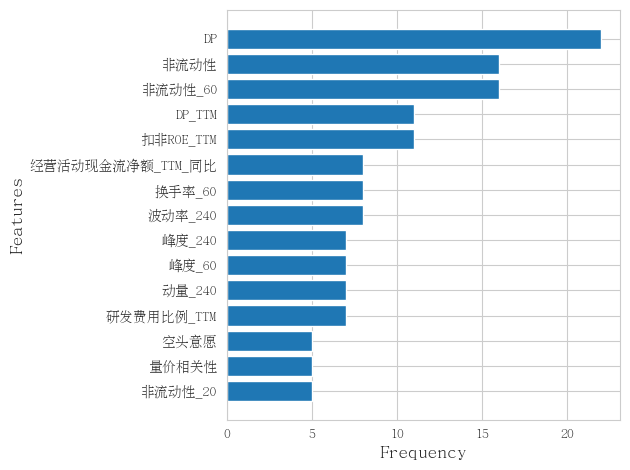

In [950]:
plt.barh(mapping_features,stock_frequency_df['frequency'][:15])
plt.xlabel('Frequency',fontsize=14)
plt.ylabel('Features',fontsize=14)
# plt.gca().set_xticks(range(0,20,2))
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/DP80_feature.svg')
# plt.close()

### 根据得到的SHAP值列表筛选特征，并画出频率图

In [864]:
#feature筛选方案
#所有基金的top5特征列表
top5_features_list=[]

#覆盖率80%重要性的特征列表
coverage80_features_list=[]

#DP特征指标80%以上卡阈值的特征列表
DP80_features_list=[]

#全部均值
importance_summary_list=[]
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    #基于SHAP平均值选择top5的特征
    top5_features=importance_summary.head(5)
    
    #选择SHAP值覆盖总重要性的80%的特征
    total_shap=importance_summary['mean'].sum()
    importance_summary['shap_cumsum']=importance_summary['mean'].cumsum()
    shap_80_percent_coverage=importance_summary[importance_summary['shap_cumsum']<=0.8*total_shap]
    
    #选择DP特征重要性大于80%的特征
    dp_threshold=importance_summary[importance_summary['features']=='CJJG_DP']['mean']*0.8
    DP80_features=importance_summary[importance_summary['mean'].values>=dp_threshold.values]
    
    DP80_features_list.append(DP80_features)
    
    coverage80_features_list.append(shap_80_percent_coverage)
    
    top5_features_list.append(top5_features)
    
    importance_summary_list.append(importance_summary)



In [218]:
#选择需要展示的特征列表
features_list=coverage80_features_list

In [221]:
feature_counter=Counter()   #特征出现次数
for feature in features_list:
    stock_names=set(feature['features'])
    feature_counter.update(feature['features']) #计数
    
#字典转换为Dataframe
stock_frequency_df=pd.DataFrame(feature_counter.items(),columns=['name','frequency'])

#按出现次数降序
stock_frequency_df=stock_frequency_df.sort_values(by=['frequency','name'],ascending=[False,True])
stock_frequency_df

,name,frequency
30,CJJG_ILQ,25
21,CJJG_ILQ_10,24
10,CJJG_POG,24
17,CJJG_RNPG,24
16,CJJG_TR_60,24
...,...,...
153,CJJG_GPM,1
156,CJJG_NPM,1
157,CJJG_NP_YOY,1
154,CJJG_RES_VOL_20,1


In [222]:
topshow=15
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in stock_frequency_df['name'][:topshow]]

In [223]:
plt.barh(mapping_features,stock_frequency_df['frequency'][:topshow])
plt.xlabel('Frequency',fontsize=14)
plt.ylabel('Features',fontsize=14)
# plt.gca().set_xticks(range(0,21,3))
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/TOP5_feature.svg')
plt.savefig(f'data/fund/fig/Coverage80_feature.svg')
# plt.savefig(f'data/fund/fig/DP80_feature.svg')
plt.close()

In [228]:
#横向拼接所有数据
importance_all_list=pd.concat(importance_summary_list)

# #按特征分组，计算特征重要性平均值，并排序
summary_all=(importance_all_list.groupby('features')['mean'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))

In [230]:
summary_all

,features,mean,std
69,CJJG_ILQ,0.500944,0.466567
72,CJJG_ILQ_60,0.376744,0.314330
34,CJJG_DP,0.296860,0.281015
35,CJJG_DP_TTM,0.284596,0.315889
96,CJJG_MOM_240,0.167193,0.114735
...,...,...,...
99,CJJG_NOPLAT2EV,0.000000,0.000000
100,CJJG_NOPLAT2EV_12,0.000000,0.000000
101,CJJG_NOPLAT2EV_12_TTM,0.000000,0.000000
104,CJJG_NOPLAT_TTM_YOY,0.000000,0.000000


In [232]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in summary_all['features'][:15]]
mapping_features

['非流动性',
 '非流动性_60',
 'DP',
 'DP_TTM',
 '动量_240',
 '换手率_60',
 '扣非ROE_TTM',
 '波动率_240',
 '盈利',
 '最大跌幅_60',
 '经营活动现金流净额_TTM_同比',
 '相对营收增长',
 '峰度_240',
 '非流动性_10',
 '空头意愿']

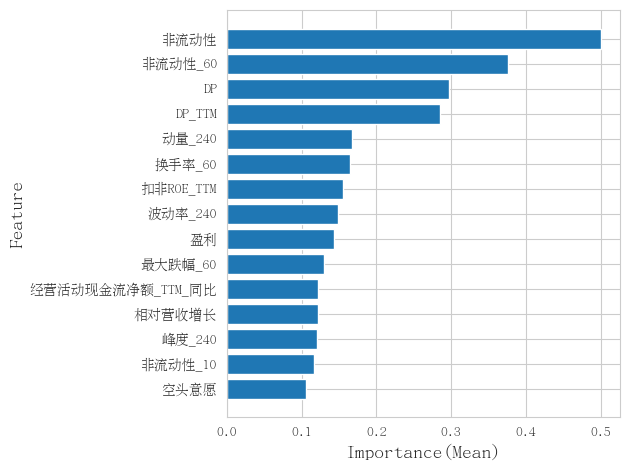

In [233]:
plt.barh(mapping_features,summary_all['mean'][:15])
plt.xlabel('Importance(Mean)',fontsize=14)
plt.ylabel('Feature',fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()

### DP的SHAP值为0的样本分析

In [243]:
#DP的SHAP值为0：004098.OF({0: 8701, 1: 3}),563180.OF({0: 4362, 1: 10}),007178.OF({0: 2974, 1: 2}),007216.OF({0: 2974, 1: 2})
#DP的SHAP值小于0.1：015290.OF({0: 12878, 1: 19})，015289.OF({0: 12878, 1: 19})，009188.OF({0.0: 30744, 1.0: 516})

In [484]:
print(tmp)

['005770.OF', 34    0.625474
Name: mean, dtype: float64, '004404.OF', 34    0.275778
Name: mean, dtype: float64, '004098.OF', 34    0.0
Name: mean, dtype: float64, '015290.OF', 34    0.00611
Name: mean, dtype: float64, '006124.OF', 34    0.340362
Name: mean, dtype: float64, '004403.OF', 34    0.297095
Name: mean, dtype: float64, '008705.OF', 34    0.183963
Name: mean, dtype: float64, '008737.OF', 34    0.516697
Name: mean, dtype: float64, '501308.OF', 34    0.981867
Name: mean, dtype: float64, '512590.OF', 34    0.449936
Name: mean, dtype: float64, '563180.OF', 34    0.0
Name: mean, dtype: float64, '009501.OF', 34    0.443973
Name: mean, dtype: float64, '515690.OF', 34    0.244492
Name: mean, dtype: float64, '008480.OF', 34    0.144996
Name: mean, dtype: float64, '008481.OF', 34    0.146987
Name: mean, dtype: float64, '004868.OF', 34    0.147013
Name: mean, dtype: float64, '501307.OF', 34    0.973809
Name: mean, dtype: float64, '007178.OF', 34    0.0
Name: mean, dtype: float64, '015289

In [488]:
print(tmp1)

['005770.OF', 14.383469523520002, '004404.OF', 13.461386542196667, '004098.OF', 1.9866943612000003, '015290.OF', 8.362932117513333, '006124.OF', 13.105480259845665, '004403.OF', 13.432690968643332, '008705.OF', 10.737664209126667, '008737.OF', 13.052217947253332, '501308.OF', 13.320632012291334, '512590.OF', 12.922877867566669, '563180.OF', 2.2229281115333333, '009501.OF', 11.630492810058, '515690.OF', 11.237521803263332, '008480.OF', 12.366531657443332, '008481.OF', 12.379775168843333, '004868.OF', 12.718112172316667, '501307.OF', 13.272719339837668, '007178.OF', 1.2600624026666667, '015289.OF', 8.385942741183335, '006123.OF', 13.069156195746665, '009500.OF', 11.594483016783332, '003702.OF', 13.932711312235334, '000916.OF', 12.065207554233334, '008736.OF', 13.072720748411, '008177.OF', 11.633733328828999, '007216.OF', 1.275302661, '008704.OF', 10.767479624243332, '009188.OF', 11.805738226416667]


In [8]:
#读取基金名称和月份数据，合并并清理空值，将每行的基金名称和其对应的非空月份分别存入两个列表
def clean_and_split_months(fund_names_path,months_path):
    #读取数据
    months_df=pd.read_csv(fund_names_path)
    fund_names_df=pd.read_csv(months_path)
    #合并数据框
    months_with_fund=pd.concat([fund_names_df,months_df],axis=1)
    #清理空值并将每一行的非空值提取为列表
    result_cleaned = months_with_fund.apply(lambda row: row.dropna().tolist(), axis=1)
    #分离基金名称和其对应的非空月份
    res = []
    for x in result_cleaned:
        if len(x) > 1:   #确保至少有基金名称和至少一个月份
            res.append(x)
    fund_names = [sublist[0] for sublist in res]
    months_list = [sublist[1:] for sublist in res]

    return fund_names,months_list

In [9]:
fund_names_path='data/fund/eda/months_df.csv'
months_path='data/fund/eda/fund_names_df.csv'
fund_names,months_list=clean_and_split_months(fund_names_path,months_path)

In [914]:
#005770.OF
fund_name='009188.OF'

In [915]:
all_data = []  # 存储所有月份的数据
for month in months_list[fund_names.index(fund_name)]:
    month=int(month)
    df = pd.read_csv(f'data/fund/eda/{fund_name}_eda_{month}.csv')
    df['month'] = month
    all_data.append(df)
    

In [916]:
data = pd.concat(all_data, ignore_index=True)
print(f'{fund_name}的eda数据shape是{data.shape}')

009188.OF的eda数据shape是(31260, 168)


In [917]:
y = data['label']
print(f'{fund_name}的y数据shape是{y.shape}')
# 统计当前类别占比情况
print(f"基金{fund_name}在Before undersampling:{Counter(y)}")

009188.OF的y数据shape是(31260,)
基金009188.OF在Before undersampling:Counter({0.0: 30744, 1.0: 516})


In [918]:
Counter(y)[1]/Counter(y)[0]>0.005

True

In [452]:
data['CJJG_DP'].describe()

count    30965.000000
mean         0.011321
std          0.015129
min          0.000000
25%          0.000418
50%          0.006495
75%          0.015570
max          0.411585
Name: CJJG_DP, dtype: float64

In [793]:
sum(data['CJJG_DP']==0)

7664

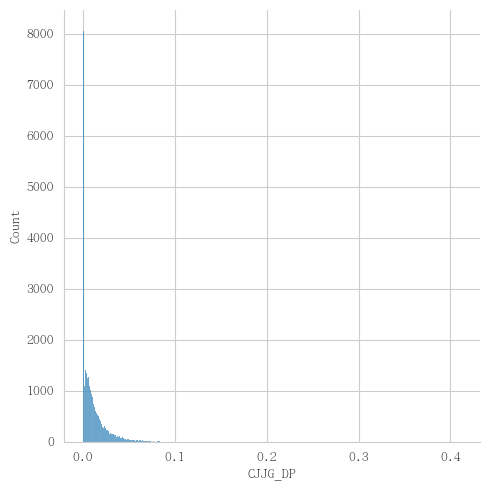

In [794]:
#直方图分布
sns.displot(data,x='CJJG_DP')

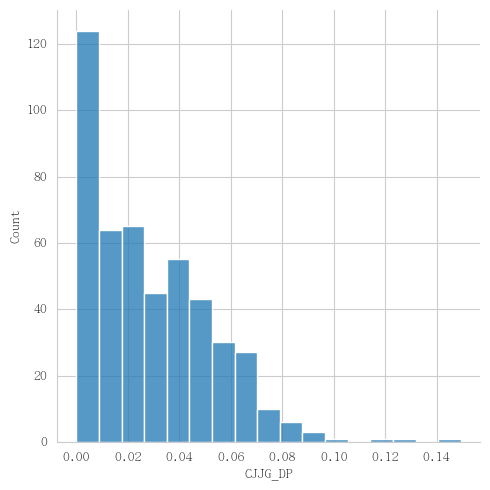

In [827]:
#直方图分布
sns.displot(data[data['label']==1],x='CJJG_DP')

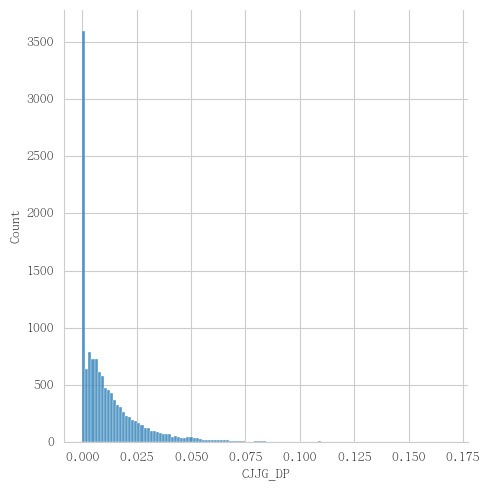

In [498]:
sns.displot(data[data['label']==0],x='CJJG_DP')

In [446]:
#计算相关系数
#Pearson相关系数，用于衡量两个连续变量之间的线性相关性
correlation_matrix=data.corr()

# #上三角掩码
# mask=np.triu(np.ones_like(correlation_matrix,dtype=bool))
# np.fill_diagonal(mask,False)

# #绘制热力图
# sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5,mask=mask)


In [447]:
correlation_matrix['CJJG_DP'].sort_values(ascending=False)

CJJG_DP            1.000000
CJJG_DP_TTM        0.987681
CJJG_EP_TTM        0.444788
CJJG_BP            0.390534
CJJG_EP            0.344764
                     ...   
CJJG_RV           -0.202605
CJJG_MIR_60       -0.223267
CJJG_VOL_60       -0.236014
CJJG_RES_VOL_60   -0.240550
CJJG_VOL_240      -0.321364
Name: CJJG_DP, Length: 167, dtype: float64

In [424]:
#计算斯皮尔曼相关系数，衡量两个变量之间的等级关系的强度和方向，不要求变量之间的关系是线性的
correlation_matrix=data.corr(method='spearman')

In [425]:
correlation_matrix['CJJG_DP'].sort_values(ascending=False)

CJJG_DP                  1.000000
CJJG_DP_TTM              0.998987
CJJG_EP_TTM              0.680563
CJJG_EBIT2EV_12_TTM      0.640962
CJJG_NOPLAT2EV_12_TTM    0.640962
                           ...   
CJJG_MA_60              -0.319256
CJJG_RES_VOL_60         -0.364670
CJJG_VOL_60             -0.369889
CJJG_VOL_240            -0.445027
month                         NaN
Name: CJJG_DP, Length: 167, dtype: float64

### 收益率计算

In [14]:
# 获取高股息的基金代码，S_INFO_OUTERCODE：基金场外代码，F_INFO_FULLNAME：基金名称
connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'"
print('从数据库中获取高股息基金数据: ' + sql)
cursor.execute(sql)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
df1 = pd.DataFrame(results, columns=columns)
print(df1)
cursor.close()
connection.close()

从数据库中获取高股息基金数据: select S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'
   S_INFO_OUTERCODE        F_INFO_NAME F_INFO_CORP_FUNDMANAGEMENTCOMP
0         005770.OF           信澳沪港深高股息                         信达澳亚基金
1         004404.OF            平安股息精选C                           平安基金
2         004098.OF         前海开源股息率50强                         前海开源基金
3         015290.OF           格林高股息优选C                           格林基金
4         006124.OF           国联高股息精选C                           国联基金
..              ...                ...                            ...
61        022073.OF    天弘中证港股通高股息投资指数C                           天弘基金
62        022274.OF    国泰中证港股通高股息投资联接A                           国泰基金
63        022145.OF       银华中证高股息策略联接C                           银华基金
64        022144.OF       银华中证高股息策略联接A                           银华基金
65        022663.OF  华泰柏瑞中证港股通高股息投资联接I                         华泰柏瑞基金

[66 rows x

In [15]:
# 获取高股息的基金经理信息，MANAGERNAME：基金经理名称，COMPNAME：基金公司名称，FDSNAME：基金简称，BEGINDATE：就职日期,ENDDATE：离职日期，ALLAVGYIELD：整体平均收益率
connection = cx_Oracle.connect('finchina', 'finchina', '10.6.60.118:1521/orcl')
cursor = connection.cursor()
sql = "SELECT MANAGERNAME,COMPNAME,FDSNAME,BEGINDATE,ENDDATE,ALLAVGYIELD FROM TQ_FD_MGPERFORMANCE where FDSNAME like '%股息%'"
print('从数据库中获取高股息基金数据: ' + sql)
cursor.execute(sql)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
df2 = pd.DataFrame(results, columns=columns)
print(df2)
cursor.close()
connection.close()

从数据库中获取高股息基金数据: SELECT MANAGERNAME,COMPNAME,FDSNAME,BEGINDATE,ENDDATE,ALLAVGYIELD FROM TQ_FD_MGPERFORMANCE where FDSNAME like '%股息%'
    MANAGERNAME       COMPNAME                   FDSNAME BEGINDATE   ENDDATE  \
0            丁尧   前海开源基金管理有限公司            前海开源股息率100强股票A  20200909  20210422   
1            冯琪     国联基金管理有限公司                  国联高股息混合A  20200622  20211122   
2            冯琪     国联基金管理有限公司                  国联高股息混合C  20200622  20211122   
3            刘威   信达澳亚基金管理有限公司            信澳中证沪港深高股息精选指数  20200415  20211117   
4            晏青     永赢基金管理有限公司                   永赢股息优选A  20200325  20231017   
..          ...            ...                       ...       ...       ...   
162         吴可凡     国泰基金管理有限公司      国泰中证港股通高股息投资ETF发起联接A  20241009  19000101   
163         吴可凡     国泰基金管理有限公司      国泰中证港股通高股息投资ETF发起联接C  20241009  19000101   
164          朱丹     国泰基金管理有限公司      国泰中证港股通高股息投资ETF发起联接A  20241009  19000101   
165          晏阳  汇添富基金管理股份有限公司  汇添富中证港股通高股息投资ETF联接(LOF)A  20230413 

In [506]:
fund_names

['005770.OF',
 '004404.OF',
 '004098.OF',
 '015290.OF',
 '006124.OF',
 '004403.OF',
 '008705.OF',
 '008737.OF',
 '501308.OF',
 '512590.OF',
 '563180.OF',
 '009501.OF',
 '515690.OF',
 '008480.OF',
 '008481.OF',
 '004868.OF',
 '501307.OF',
 '007178.OF',
 '015289.OF',
 '006123.OF',
 '009500.OF',
 '003702.OF',
 '000916.OF',
 '008736.OF',
 '008177.OF',
 '007216.OF',
 '008704.OF',
 '009188.OF']

In [17]:
fund_info=df1[df1['S_INFO_OUTERCODE'].isin(fund_names)]

In [517]:
FUNDMANAGEMENTCOMP=df1[df1['S_INFO_OUTERCODE'].isin(fund_names)]['F_INFO_CORP_FUNDMANAGEMENTCOMP']
FUNDMANAGEMENTCOMP

0      信达澳亚基金
1        平安基金
2      前海开源基金
3        格林基金
4        国联基金
7        平安基金
8        广发基金
10       南方基金
13       银河基金
16     浦银安盛基金
17       银华基金
24     国寿安保基金
25       鹏华基金
26       永赢基金
28       永赢基金
29    交银施罗德基金
39       银河基金
41       浙商基金
42       格林基金
43       国联基金
44     国寿安保基金
45       平安基金
46     前海开源基金
49       南方基金
51       建信基金
54       浙商基金
55       广发基金
57       鹏华基金
Name: F_INFO_CORP_FUNDMANAGEMENTCOMP, dtype: object

In [566]:
df2.columns

Index(['MANAGERNAME', 'COMPNAME', 'FDSNAME', 'BEGINDATE', 'ENDDATE',
       'ALLAVGYIELD'],
      dtype='object')

In [567]:
filtered_df=df2[df2['COMPNAME'].str[:4].isin([name[:4] for name in FUNDMANAGEMENTCOMP])]

In [6]:
filtered_df

NameError: name 'filtered_df' is not defined

In [978]:
filtered_df[filtered_df['COMPNAME'].str.contains('平安基金')]
#201712-202406---78      #43,17,27,29,78   43/78*5.498+17/78*20.54+27/78*19.487+29/78*12.056
#43,17,27,29 43/78*5.498+17/78*20.54+27/78*19.487+29/78*12.056
#33，28，36 33/36*13.439+28/36*23.24
#(42/78)*5.49+()

,MANAGERNAME,COMPNAME,FDSNAME,BEGINDATE,ENDDATE,ALLAVGYIELD
22,成钧,平安基金管理有限公司,平安股息精选沪港深股票A,20200624,20240103,5.4958
23,毛时超,平安基金管理有限公司,平安股息精选沪港深股票A,20200624,20211105,20.5401
24,成钧,平安基金管理有限公司,平安股息精选沪港深股票C,20200624,20240103,5.4981
25,毛时超,平安基金管理有限公司,平安股息精选沪港深股票C,20200624,20211105,20.5401
69,施旭,平安基金管理有限公司,平安中证沪港深高股息指数,20170125,20191021,13.4390
70,钱晶,平安基金管理有限公司,平安中证沪港深高股息指数,20180326,20200702,23.2403
76,孙东宁,平安基金管理有限公司,平安股息精选沪港深股票A,20180307,20200629,19.5140
77,施旭,平安基金管理有限公司,平安股息精选沪港深股票A,20170517,20191021,12.0570
78,孙东宁,平安基金管理有限公司,平安股息精选沪港深股票C,20180307,20200629,19.4870
79,施旭,平安基金管理有限公司,平安股息精选沪港深股票C,20170517,20191021,12.0565


In [632]:
result=(33/36*13.439)+(28/36*23.24)
result

30.394638888888885

In [705]:
tmp=filtered_df[filtered_df['COMPNAME'].str.contains('平安基金')]
# tmp['BEGINDATE']

In [631]:
from datetime import datetime
date1=tmp['BEGINDATE'][70]
date2=tmp['ENDDATE'][70]
# date1='20170601'
# date2='20200601'
d1=datetime.strptime(date1,'%Y%m%d')
d2=datetime.strptime(date2,'%Y%m%d')
months_diff=(d2.year-d1.year)*12+(d2.month-d1.month)
months_diff

36

In [706]:
fund_info[fund_info['F_INFO_CORP_FUNDMANAGEMENTCOMP']=='建信基金']

,S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP,ALLAVGYIELD,START_DATE,LAST_DATE
51,008177.OF,建信高股息主题,建信基金,0.0,202006.0,202406.0


In [43]:
fund_info

,S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP,ALLAVGYIELD
0,005770.OF,信澳沪港深高股息,信达澳亚基金,35.73
1,004404.OF,平安股息精选C,平安基金,18.74
4,006124.OF,国联高股息精选C,国联基金,22.67
7,004403.OF,平安股息精选A,平安基金,18.73
8,008705.OF,广发高股息优享C,广发基金,9.33
10,008737.OF,南方高股息主题C,南方基金,6.68
13,501308.OF,银河中证沪港深高股息C,银河基金,3.99
16,512590.OF,高股息ETF,浦银安盛基金,41.00
24,009501.OF,国寿安保高股息C,国寿安保基金,1.13
25,515690.OF,股息ETF,鹏华基金,30.00


In [42]:
fund_info.loc[57,'ALLAVGYIELD']=8.3

In [709]:
fund_info

,S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP,ALLAVGYIELD,START_DATE,LAST_DATE
0,005770.OF,信澳沪港深高股息,信达澳亚基金,35.73,201906.0,202212.0
1,004404.OF,平安股息精选C,平安基金,18.74,201712.0,202406.0
2,004098.OF,前海开源股息率50强,前海开源基金,9.10,202312.0,202406.0
3,015290.OF,格林高股息优选C,格林基金,0.39,202306.0,202406.0
4,006124.OF,国联高股息精选C,国联基金,22.67,201912.0,202406.0
7,004403.OF,平安股息精选A,平安基金,18.73,201712.0,202406.0
8,008705.OF,广发高股息优享C,广发基金,9.33,202006.0,202406.0
10,008737.OF,南方高股息主题C,南方基金,6.68,202012.0,202406.0
13,501308.OF,银河中证沪港深高股息C,银河基金,3.99,201806.0,202406.0
16,512590.OF,高股息ETF,浦银安盛基金,41.00,201903.0,202212.0


##### 浙商基金,银华基金 开始与结束日期相同

In [713]:
#DP的SHAP值小于0.1且正样本过少：004098.OF({0: 8701, 1: 3}),563180.OF({0: 4362, 1: 10}),007178.OF({0: 2974, 1: 2}),007216.OF({0: 2974, 1: 2})，015290.OF({0: 12878, 1: 19})，015289.OF({0: 12878, 1: 19})
remove_list=['004098.OF','563180.OF','007178.OF','007216.OF','015290.OF','015289.OF']
fund_filter_info=fund_info[~fund_info['S_INFO_OUTERCODE'].isin(remove_list)]

In [711]:
fund_filter_info

,S_INFO_OUTERCODE,F_INFO_NAME,F_INFO_CORP_FUNDMANAGEMENTCOMP,ALLAVGYIELD,START_DATE,LAST_DATE
0,005770.OF,信澳沪港深高股息,信达澳亚基金,35.73,201906.0,202212.0
1,004404.OF,平安股息精选C,平安基金,18.74,201712.0,202406.0
4,006124.OF,国联高股息精选C,国联基金,22.67,201912.0,202406.0
7,004403.OF,平安股息精选A,平安基金,18.73,201712.0,202406.0
8,008705.OF,广发高股息优享C,广发基金,9.33,202006.0,202406.0
10,008737.OF,南方高股息主题C,南方基金,6.68,202012.0,202406.0
13,501308.OF,银河中证沪港深高股息C,银河基金,3.99,201806.0,202406.0
16,512590.OF,高股息ETF,浦银安盛基金,41.00,201903.0,202212.0
24,009501.OF,国寿安保高股息C,国寿安保基金,1.13,202012.0,202406.0
25,515690.OF,股息ETF,鹏华基金,30.00,202005.0,202106.0


In [44]:
fund_filter_info=fund_info

In [45]:
fund_filter_info.to_csv(f'data/fund/analyze/fund_filter_info.csv', index=False)

### 根据基金收益对SHAP进行加权

In [979]:
#feature筛选方案
#全部均值
importance_summary_list=[]
total_ALLAVGYIELD=sum(fund_filter_info['ALLAVGYIELD'])
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    
    weight=(fund_filter_info[fund_filter_info['S_INFO_OUTERCODE']==fund_name]['ALLAVGYIELD'])/total_ALLAVGYIELD
    print(f'{fund_name}的权重为{weight.values[0]}')
    
    importance_summary['weight_shap']=importance_summary['mean']*weight.values[0]
    importance_summary_list.append(importance_summary)



005770.OF的权重为0.09799511807136391
004404.OF的权重为0.05139738350566358
006124.OF的权重为0.062176023696552486
004403.OF的权重为0.051369956940292366
008705.OF的权重为0.025588985491346916
008737.OF的权重为0.018320945667973997
501308.OF的权重为0.010943199583116207
512590.OF的权重为0.1124489180219961
009501.OF的权重为0.003099201886947697
515690.OF的权重为0.08227969611365568
008480.OF的权重为0.034749458325333916
008481.OF的权重为0.034749458325333916
004868.OF的权重为0.11288774306793559
501307.OF的权重为0.015660568826965798
006123.OF的权重为0.0270425934560215
009500.OF的权重为0.015633142261594582
003702.OF的权重为0.049779216148761685
000916.OF的权重为0.06116124077781739
008736.OF的权重为0.01829351910260278
008177.OF的权重为0.05669071062230877
008704.OF的权重为0.03496887084830366
009188.OF的权重为0.02276404925811141


In [980]:
importance_summary

,features,mean,std,weight_shap
118,CJJG_PFT,0.399412,0.056909,0.009092
69,CJJG_ILQ,0.354441,0.047739,0.008069
2,CJJG_ANPG,0.322223,0.043138,0.007335
107,CJJG_NPAT_YOY,0.309728,0.088188,0.007051
158,CJJG_TR_60,0.201425,0.036921,0.004585
...,...,...,...,...
104,CJJG_NOPLAT_TTM_YOY,0.000000,0.000000,0.000000
100,CJJG_NOPLAT2EV_12,0.000000,0.000000,0.000000
105,CJJG_NOPLAT_YOY,0.000000,0.000000,0.000000
101,CJJG_NOPLAT2EV_12_TTM,0.000000,0.000000,0.000000


In [981]:
#横向拼接所有数据
importance_all_list=pd.concat(importance_summary_list)

# #按特征分组，计算特征重要性平均值，并排序
summary_all=(importance_all_list.groupby('features')['mean'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))

In [982]:
summary_all

,features,mean,std
69,CJJG_ILQ,0.597712,0.465215
72,CJJG_ILQ_60,0.475569,0.286272
34,CJJG_DP,0.384742,0.272572
35,CJJG_DP_TTM,0.352654,0.316253
158,CJJG_TR_60,0.198885,0.078097
...,...,...,...
104,CJJG_NOPLAT_TTM_YOY,0.000000,0.000000
99,CJJG_NOPLAT2EV,0.000000,0.000000
102,CJJG_NOPLAT2EV_TTM,0.000000,0.000000
101,CJJG_NOPLAT2EV_12_TTM,0.000000,0.000000


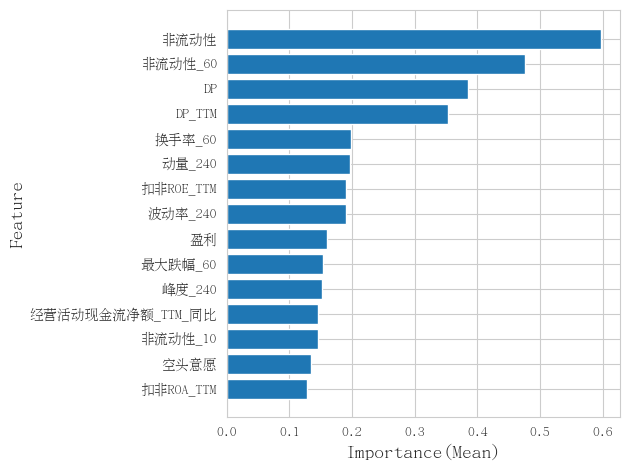

In [985]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in summary_all['features'][:15]]
plt.barh(mapping_features,summary_all['mean'][:15])
plt.xlabel('Importance(Mean)',fontsize=14)
plt.ylabel('Feature',fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/Weighted_SHAP_feature.svg')
# plt.close()

In [890]:
list(summary_all['features'][:15])

['CJJG_ILQ',
 'CJJG_ILQ_60',
 'CJJG_DP',
 'CJJG_DP_TTM',
 'CJJG_TR_60',
 'CJJG_MOM_240',
 'CJJG_ENIROE_TTM',
 'CJJG_VOL_240',
 'CJJG_PFT',
 'CJJG_MDR_60',
 'CJJG_KU_240',
 'CJJG_NCFOA_TTM_YOY',
 'CJJG_ILQ_10',
 'CJJG_BI',
 'CJJG_ILQ_20']

### top5特征筛选，收益率高的一次加的数>1，收益率低的一次加的数<1

In [46]:
#所有基金的top5特征列表
top5_features_list=[]
for fund_name in fund_names:
    base_dir=f'data/fund/model/{fund_name}'
    feature_file_names=[f'{base_dir}/xgb_{fund_name}_feature_importance{i}.csv' for i in range(30)]
    
    importance_features = []     
    for file in feature_file_names:
        df=pd.read_csv(file)
        importance_features.append(df)
        
    #横向拼接所有数据
    importance_all=pd.concat(importance_features)
    
    #按特征分组，计算特征重要性平均值，并排序
    importance_summary=(importance_all.groupby('features')['shap_values'].agg(['mean','std']).reset_index().sort_values(by='mean',ascending=False))
    importance_summary['fund_name']=fund_name
    

    
   #基于SHAP平均值选择top5的特征
    top5_features=importance_summary[['features','fund_name']].head(5)

    
    top5_features_list.append(top5_features)
    
    # #替换特征名字，如果找不到映射，使用原名字
    # mapping_features=[mapping_dict.get(feature) for feature in top15_features['features']]

In [47]:
top5_features_list[0]

,features,fund_name
5,CJJG_ARR_TTM,005770.OF
34,CJJG_DP,005770.OF
97,CJJG_NCFOA_TTM_YOY,005770.OF
58,CJJG_ENIROA_TTM,005770.OF
3,CJJG_ARG,005770.OF


In [48]:
#计算得到收益中位数
profit_res=[]
for fund_name in fund_names:
    res=fund_filter_info[fund_filter_info['S_INFO_OUTERCODE']==fund_name]
    profit_res.append(res[['S_INFO_OUTERCODE','ALLAVGYIELD']])
all_profits=pd.concat([df['ALLAVGYIELD'] for df in profit_res])
global_median=all_profits.median()

In [49]:
global_median

12.71

In [50]:
#添加label列，表明收益率高低
process_dataframes=[]
for df in profit_res:
    df['label']=df['ALLAVGYIELD'].apply(lambda x:'高收益率' if x>global_median else '低收益率')
    process_dataframes.append(df)

In [51]:
process_dataframe=pd.concat(df for df in process_dataframes)
process_dataframe

,S_INFO_OUTERCODE,ALLAVGYIELD,label
0,005770.OF,35.73,高收益率
1,004404.OF,18.74,高收益率
4,006124.OF,22.67,高收益率
7,004403.OF,18.73,高收益率
8,008705.OF,9.33,低收益率
10,008737.OF,6.68,低收益率
13,501308.OF,3.99,低收益率
16,512590.OF,41.00,高收益率
24,009501.OF,1.13,低收益率
25,515690.OF,30.00,高收益率


In [52]:
#权重设置
weight_mapping={'高收益率':1.5,'低收益率':0.5}

#统计特征频率
feature_counts=Counter()

for df in top5_features_list:
    fund_name=df['fund_name'].iloc[0]  #获取当前基金名称
    if fund_name in process_dataframe['S_INFO_OUTERCODE'].values:
        label=process_dataframe.loc[process_dataframe['S_INFO_OUTERCODE']==fund_name,'label'].values[0]
        weight=weight_mapping.get(label,1)   #根据收益率标注获取权重
        for feature in df['features']:
            feature_counts[feature]+=weight

In [53]:
#字典转换为Dataframe
stock_frequency_df=pd.DataFrame(feature_counts.items(),columns=['name','frequency'])

#按出现次数降序
stock_frequency_df=stock_frequency_df.sort_values(by='frequency',ascending=False)
stock_frequency_df



,name,frequency
5,CJJG_ILQ,13.5
6,CJJG_ILQ_60,13.0
1,CJJG_DP,11.5
8,CJJG_DP_TTM,11.0
9,CJJG_MOM_240,6.5
7,CJJG_VOL_240,6.5
13,CJJG_PFT,4.5
2,CJJG_NCFOA_TTM_YOY,4.5
3,CJJG_ENIROA_TTM,4.5
19,CJJG_TR_60,3.5


In [59]:
#替换特征名字，如果找不到映射，使用原名字
mapping_features=[mapping_dict.get(feature) for feature in stock_frequency_df['name'][:15]]

In [61]:
mapping_features

['非流动性',
 '非流动性_60',
 'DP',
 'DP_TTM',
 '动量_240',
 '波动率_240',
 '盈利',
 '经营活动现金流净额_TTM_同比',
 '扣非ROA_TTM',
 '换手率_60',
 '峰度_240',
 'ROA_TTM',
 '扣非ROE_TTM',
 '峰度_60',
 '最大跌幅_60']

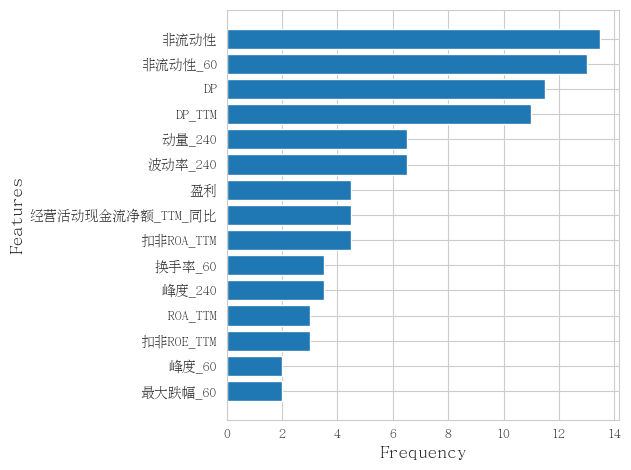

In [60]:
plt.barh(mapping_features,stock_frequency_df['frequency'][:15])
plt.xlabel('Frequency',fontsize=14)
plt.ylabel('Features',fontsize=14)
# plt.gca().set_xticks(range(0,20,2))
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig(f'data/fund/fig/Weighted_SHAP_feature_Top5.svg')
# plt.close()